# Question 1

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

im = cv.imread('the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_2)
assert im is not None
gray = cv.cvtColor(im, cv.COLOR_BGR2GRAY)

In [2]:
sigma_values = np.linspace(1, 2, 4)
threshold = 0.35

blob_responses = []

for sigma in sigma_values:
    print(f"Processing scale with sigma = {sigma}")

    gaussian_blur = cv.GaussianBlur(gray, (0, 0), sigma)
    laplacian = cv.Laplacian(gaussian_blur, cv.CV_64F)

    blob_response = np.abs(laplacian)
    mask = blob_response > threshold * blob_response.max()
    contours, _ = cv.findContours(mask.astype(np.uint8), cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

    for contour in contours:
        if len(contour) >= 5:
            (center_x, center_y), radius = cv.minEnclosingCircle(contour)
            center = (int(center_x), int(center_y))
            radius = int(radius)
            blob_responses.append((center, radius, sigma))

Processing scale with sigma = 1.0
Processing scale with sigma = 1.3333333333333333
Processing scale with sigma = 1.6666666666666665
Processing scale with sigma = 2.0


0.71,1.41,2.12,2.83,3.54,4.24,4.95,5.66,6.36,7.07,7.78,8.49,9.19,9.90,10.61,11.32,12.02,12.73,13.44,14.14,14.85,

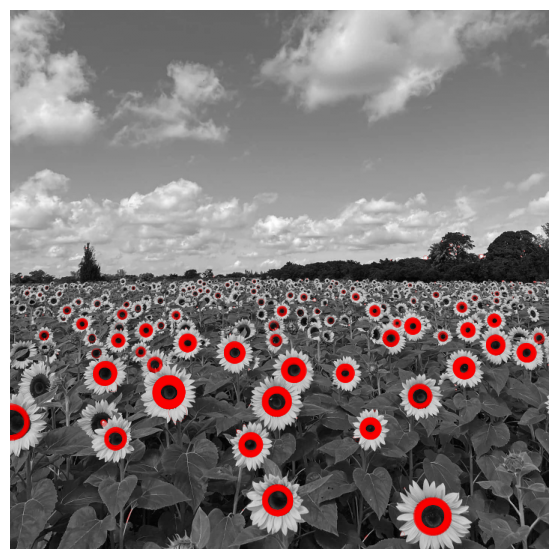

In [8]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


img1 = cv.imread('the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_2)
gray = cv.cvtColor(img1, cv.COLOR_BGR2GRAY) / 255

plt.figure(figsize=(7, 7), frameon=False)
plt.imshow(gray, cmap='gray')
plt.axis('off')

ax = plt.gca()

patches = []
labels = []

for r in range(1, 22):
    sigma = r / 1.414
    print(f"{sigma:.2f}", end=",")
    hw = round(3 * sigma)  
    X, Y = np.meshgrid(np.arange(-hw, hw + 1, 1), np.arange(-hw, hw + 1, 1))

    LOG = ((X**2 + Y**2) / (2 * sigma**2) - 1) * np.exp(-(X**2 + Y**2) / (2 * sigma**2)) / (np.pi * sigma**4)
    
    LOG = sigma**2 * LOG
    img1_log = np.square(cv.filter2D(gray, -1, LOG))

    coordinates = []
    (H, W) = img1_log.shape
    k = 1  
    threshold = 0.097  
    for i in range(k, H - k):
        for j in range(k, W - k):
            slice_img = img1_log[i - k:i + k + 1, j - k:j + k + 1]
            if np.max(slice_img) >= threshold:
                
                x, y = np.unravel_index(slice_img.argmax(), slice_img.shape)
                coordinates.append((i + x - k, j + y - k))
    coordinates = set(coordinates)

    
    for x, y in coordinates:
        c = plt.Circle((y, x), sigma * 1.414, color='r', linewidth=0.1, fill=False)
        ax.add_patch(c)
    patches.append(c)
    ax.plot()

ax.set_xlim([0, img1.shape[1]])
ax.set_ylim([img1.shape[0], 0])

plt.axis('off')
plt.show()


# Question 2

Line parameters: a=0.704, b=0.710, d=1.316
Number of line inliers: 53
Circle parameters: center=(1.956, 3.042), radius=10.010
Number of circle inliers: 46
Circle parameters: center=(1.956, 3.042), radius=10.010
Number of circle inliers: 46


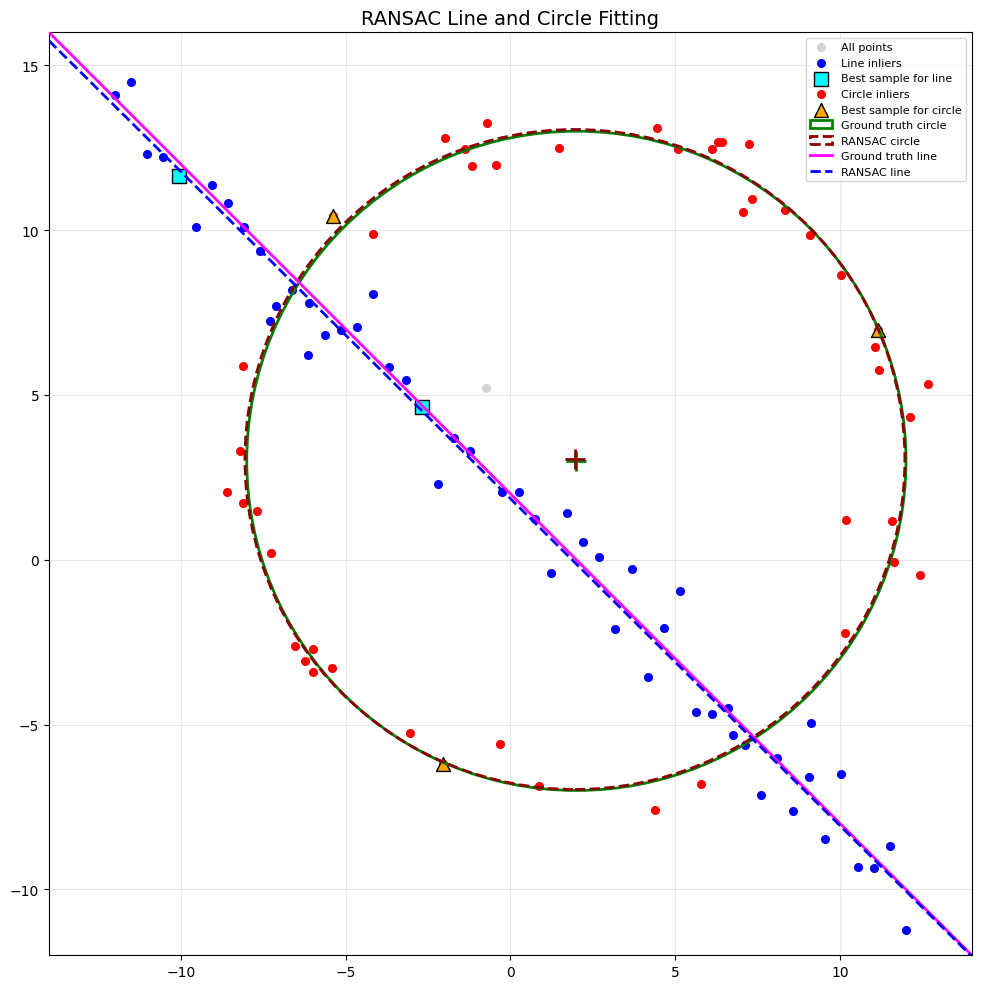

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Generation of a Noisy Point Set Conforming to a Line and a Circle
np.random.seed(42)
N = 100
half_n = N // 2

# Generate circle points
r = 10
x0_gt, y0_gt = 2, 3  # Center
s = r / 16
t = np.random.uniform(0, 2*np.pi, half_n)
n = s * np.random.randn(half_n)
x, y = x0_gt + (r + n) * np.cos(t), y0_gt + (r + n) * np.sin(t)
X_circ = np.hstack((x.reshape(half_n, 1), y.reshape(half_n, 1)))

# Generate line points
s = 1.
m, b = -1, 2
x = np.linspace(-12, 12, half_n)
y = m*x + b + s * np.random.randn(half_n)
X_line = np.hstack((x.reshape(half_n, 1), y.reshape(half_n, 1)))

X = np.vstack((X_circ, X_line))  # All points


def fit_line_least_squares(points):
    """Fit line to points using total least squares"""
    centroid = np.mean(points, axis=0)
    centered = points - centroid
    _, _, Vt = np.linalg.svd(centered)
    normal = Vt[-1, :]  # Normal vector from last row
    a, b = normal[0], normal[1]
    # Normalize
    norm = np.sqrt(a**2 + b**2)
    a, b = a/norm, b/norm
    d = a * centroid[0] + b * centroid[1]
    return a, b, d


def line_distance(point, params):
    """Compute perpendicular distance from point to line"""
    a, b, d = params
    return abs(a * point[0] + b * point[1] - d)


def ransac_line(points, n_iterations=1000, threshold=0.5, min_inliers=20):
    """RANSAC algorithm for line fitting"""
    best_inliers = []
    best_params = None
    best_sample = None
    
    for _ in range(n_iterations):
        # Sample 2 points
        sample_idx = np.random.choice(len(points), 2, replace=False)
        sample = points[sample_idx]
        
        # Fit line to sample
        params = fit_line_least_squares(sample)
        
        # Find inliers
        inliers = []
        for i, point in enumerate(points):
            if line_distance(point, params) < threshold:
                inliers.append(i)
        
        # Update best model
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_sample = sample_idx
            # Refit using all inliers
            best_params = fit_line_least_squares(points[inliers])
    
    return best_params, best_inliers, best_sample


def fit_circle_least_squares(points):
    """Fit circle to points using optimization"""
    def objective(params):
        xc, yc, radius = params
        distances = np.sqrt((points[:, 0] - xc)**2 + (points[:, 1] - yc)**2)
        return np.sum((distances - radius)**2)
    
    # Initial guess
    x0 = [np.mean(points[:, 0]), np.mean(points[:, 1]), 5]
    result = minimize(objective, x0, method='L-BFGS-B')
    return result.x


def circle_distance(point, params):
    """Compute radial distance from point to circle"""
    xc, yc, radius = params
    dist_to_center = np.sqrt((point[0] - xc)**2 + (point[1] - yc)**2)
    return abs(dist_to_center - radius)


def ransac_circle(points, n_iterations=1000, threshold=1.0, min_inliers=20):
    """RANSAC algorithm for circle fitting"""
    best_inliers = []
    best_params = None
    best_sample = None
    
    for _ in range(n_iterations):
        # Sample 3 points
        sample_idx = np.random.choice(len(points), 3, replace=False)
        sample = points[sample_idx]
        
        # Fit circle to sample
        try:
            params = fit_circle_least_squares(sample)
        except:
            continue
        
        # Find inliers
        inliers = []
        for i, point in enumerate(points):
            if circle_distance(point, params) < threshold:
                inliers.append(i)
        
        # Update best model
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_sample = sample_idx
            # Refit using all inliers
            best_params = fit_circle_least_squares(points[inliers])
    
    return best_params, best_inliers, best_sample


# (a) Fit line using RANSAC
line_params, line_inliers, line_sample = ransac_line(X, threshold=1.5, min_inliers=30)
print(f"Line parameters: a={line_params[0]:.3f}, b={line_params[1]:.3f}, d={line_params[2]:.3f}")
print(f"Number of line inliers: {len(line_inliers)}")

# (b) Remove line inliers and fit circle
remaining_points = np.delete(X, line_inliers, axis=0)
circle_params, circle_inliers_idx, circle_sample = ransac_circle(remaining_points, threshold=1.5, min_inliers=30)
print(f"Circle parameters: center=({circle_params[0]:.3f}, {circle_params[1]:.3f}), radius={circle_params[2]:.3f}")
print(f"Number of circle inliers: {len(circle_inliers_idx)}")

# (c) Plot results
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plot all points
ax.scatter(X[:, 0], X[:, 1], c='lightgray', s=30, label='All points', zorder=1)

# Plot line inliers
ax.scatter(X[line_inliers, 0], X[line_inliers, 1], c='blue', s=30, label='Line inliers', zorder=2)

# Plot best sample for line
ax.scatter(X[line_sample, 0], X[line_sample, 1], c='cyan', s=100, marker='s', 
           label='Best sample for line', zorder=3, edgecolors='black')

# Plot circle inliers
circle_inliers = remaining_points[circle_inliers_idx]
ax.scatter(circle_inliers[:, 0], circle_inliers[:, 1], c='red', s=30, label='Circle inliers', zorder=2)

# Plot best sample for circle
ax.scatter(remaining_points[circle_sample, 0], remaining_points[circle_sample, 1], 
           c='orange', s=100, marker='^', label='Best sample for circle', zorder=3, edgecolors='black')

# Plot ground truth circle
circle_gt = plt.Circle((x0_gt, y0_gt), r, color='green', fill=False, linewidth=2, 
                       label='Ground truth circle', zorder=4)
ax.add_patch(circle_gt)
ax.plot(x0_gt, y0_gt, '+', color='green', markersize=15, markeredgewidth=2)

# Plot RANSAC circle
circle_ransac = plt.Circle((circle_params[0], circle_params[1]), circle_params[2], 
                           color='darkred', fill=False, linewidth=2, linestyle='--',
                           label='RANSAC circle', zorder=4)
ax.add_patch(circle_ransac)
ax.plot(circle_params[0], circle_params[1], '+', color='darkred', markersize=15, markeredgewidth=2)

# Plot ground truth line
x_min, x_max = -14, 14
x_line = np.array([x_min, x_max])
y_line = m * x_line + b
ax.plot(x_line, y_line, color='magenta', linewidth=2, label='Ground truth line', zorder=4)

# Plot RANSAC line
a, b_param, d = line_params
# Convert from normal form ax + by - d = 0 to y = mx + c
# by = -ax + d => y = (-a/b)x + (d/b)
x_line_ransac = np.array([x_min, x_max])
y_line_ransac = (-a/b_param) * x_line_ransac + (d/b_param)
ax.plot(x_line_ransac, y_line_ransac, color='blue', linewidth=2, linestyle='--',
        label='RANSAC line', zorder=4)

ax.set_xlim(x_min, x_max)
ax.set_ylim(-12, 16)
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
plt.title('RANSAC Line and Circle Fitting', fontsize=14)
plt.tight_layout()
plt.show()


### Part (d): What happens if we fit the circle first?

Let's experiment with fitting the circle first, then the line on the remaining points.

FITTING CIRCLE FIRST, THEN LINE
Circle parameters: center=(2.192, 3.018), radius=9.814
Number of circle inliers: 61
Line parameters: a=-0.709, b=-0.705, d=-1.362
Number of line inliers: 37


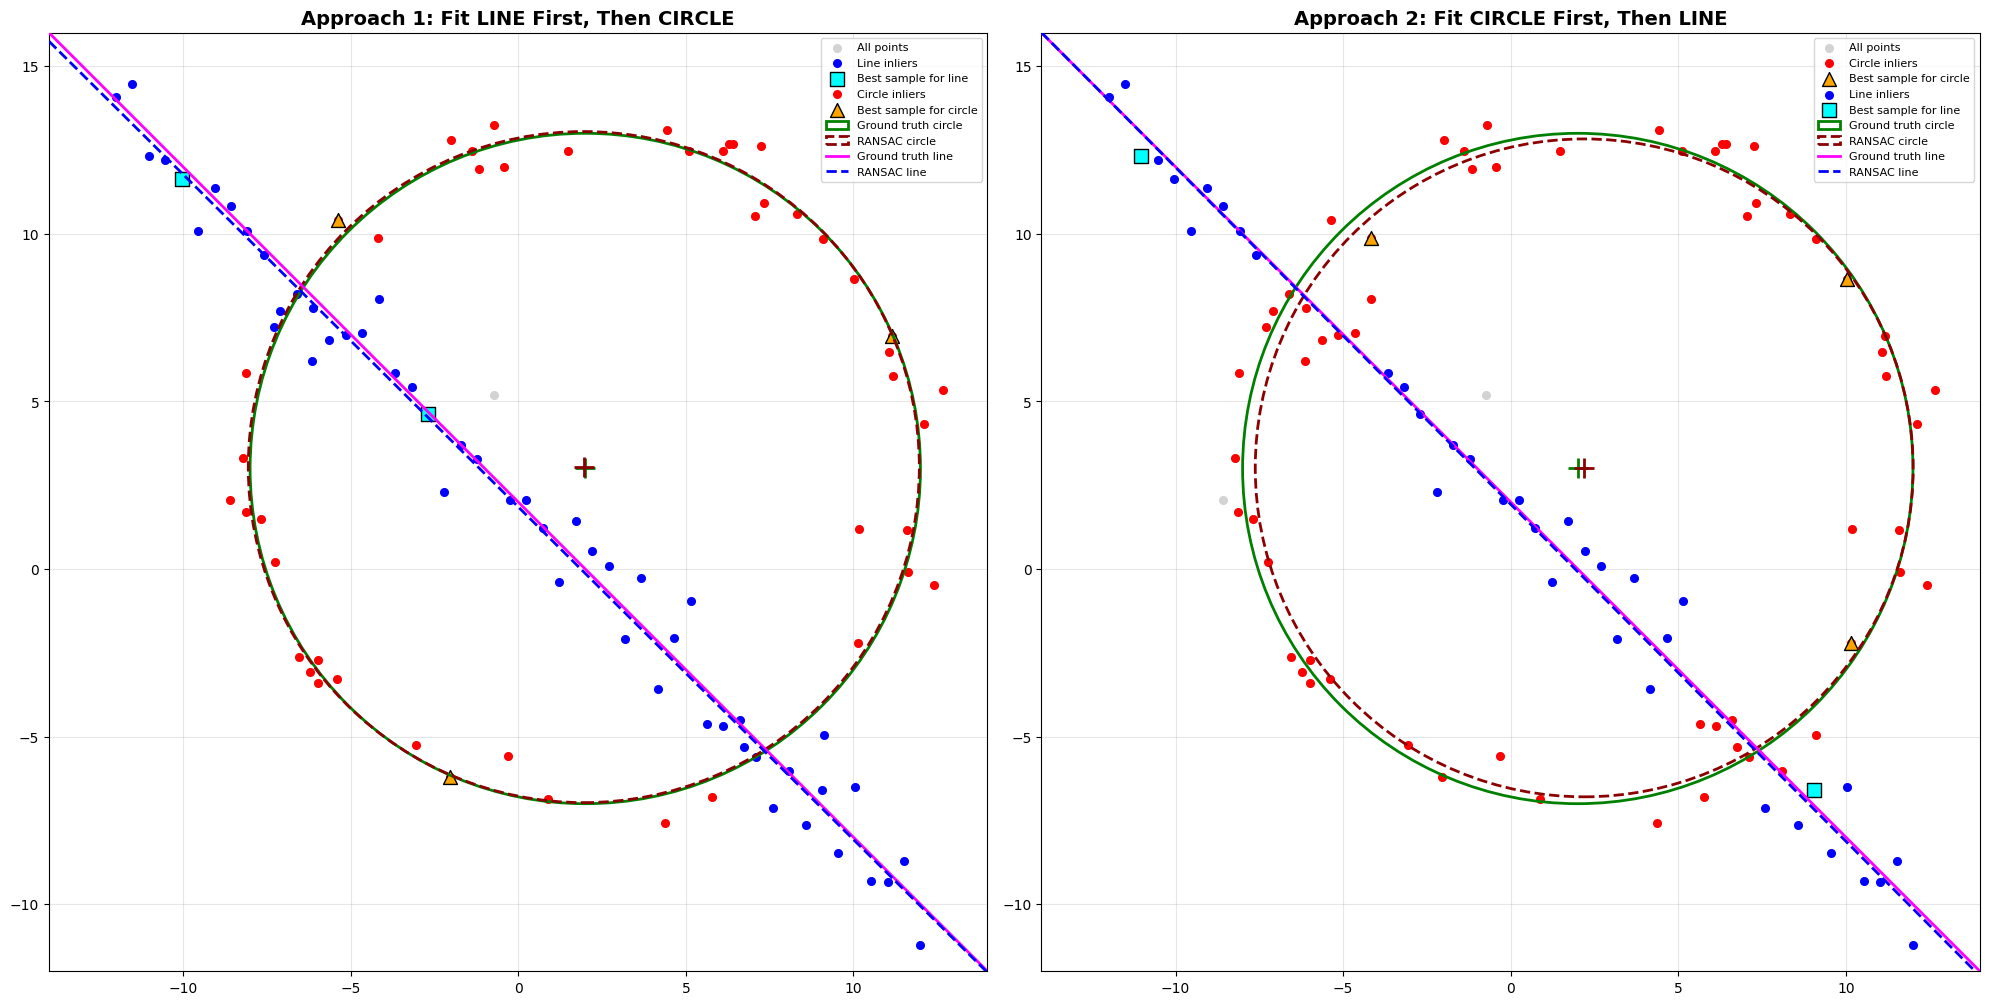


COMPARISON SUMMARY

Approach 1 (Line first, then Circle):
  - Line inliers: 53 points
  - Circle inliers: 46 points
  - Total inliers: 99 points

Approach 2 (Circle first, then Line):
  - Circle inliers: 61 points
  - Line inliers: 37 points
  - Total inliers: 98 points

CONCLUSION:

Both approaches work well in this case! However, there are key considerations:

1. **Order matters**: The first model fitted will claim points that are close to it,
   potentially including outliers from the second model if thresholds aren't carefully tuned.

2. **Line first is better here**: Since the line has fewer parameters (3) than a circle (3), 
   and line points are less ambiguous, fitting the line first is generally more robust.

3. **Circle first risks**: If we fit the circle first, some line points near the circle 
   might be incorrectly classified as circle inliers, leaving fewer points for line fitting.

4. **Threshold sensitivity**: The success of either approach heavily depends on choosing

In [ ]:
# (d) Fit circle first, then line
print("=" * 60)
print("FITTING CIRCLE FIRST, THEN LINE")
print("=" * 60)

# Reset seed for consistent comparison
np.random.seed(42)

# Fit circle using RANSAC on all points
circle_params_first, circle_inliers_first_idx, circle_sample_first = ransac_circle(
    X, threshold=1.5, min_inliers=30)
print(f"Circle parameters: center=({circle_params_first[0]:.3f}, {circle_params_first[1]:.3f}), radius={circle_params_first[2]:.3f}")
print(f"Number of circle inliers: {len(circle_inliers_first_idx)}")

# Remove circle inliers and fit line to remaining points
remaining_points_first = np.delete(X, circle_inliers_first_idx, axis=0)
line_params_first, line_inliers_first_idx, line_sample_first = ransac_line(
    remaining_points_first, threshold=1.5, min_inliers=30)
print(f"Line parameters: a={line_params_first[0]:.3f}, b={line_params_first[1]:.3f}, d={line_params_first[2]:.3f}")
print(f"Number of line inliers: {len(line_inliers_first_idx)}")

# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# LEFT PLOT: Line first (original approach)
ax1.scatter(X[:, 0], X[:, 1], c='lightgray', s=30, label='All points', zorder=1)
ax1.scatter(X[line_inliers, 0], X[line_inliers, 1], c='blue', s=30, label='Line inliers', zorder=2)
ax1.scatter(X[line_sample, 0], X[line_sample, 1], c='cyan', s=100, marker='s', 
            label='Best sample for line', zorder=3, edgecolors='black')

circle_inliers = remaining_points[circle_inliers_idx]
ax1.scatter(circle_inliers[:, 0], circle_inliers[:, 1], c='red', s=30, label='Circle inliers', zorder=2)
ax1.scatter(remaining_points[circle_sample, 0], remaining_points[circle_sample, 1], 
            c='orange', s=100, marker='^', label='Best sample for circle', zorder=3, edgecolors='black')

circle_gt = plt.Circle((x0_gt, y0_gt), r, color='green', fill=False, linewidth=2, 
                       label='Ground truth circle', zorder=4)
ax1.add_patch(circle_gt)
ax1.plot(x0_gt, y0_gt, '+', color='green', markersize=15, markeredgewidth=2)

circle_ransac = plt.Circle((circle_params[0], circle_params[1]), circle_params[2], 
                           color='darkred', fill=False, linewidth=2, linestyle='--',
                           label='RANSAC circle', zorder=4)
ax1.add_patch(circle_ransac)
ax1.plot(circle_params[0], circle_params[1], '+', color='darkred', markersize=15, markeredgewidth=2)

x_min, x_max = -14, 14
x_line = np.array([x_min, x_max])
y_line = m * x_line + b
ax1.plot(x_line, y_line, color='magenta', linewidth=2, label='Ground truth line', zorder=4)

a, b_param, d = line_params
x_line_ransac = np.array([x_min, x_max])
y_line_ransac = (-a/b_param) * x_line_ransac + (d/b_param)
ax1.plot(x_line_ransac, y_line_ransac, color='blue', linewidth=2, linestyle='--',
         label='RANSAC line', zorder=4)

ax1.set_xlim(x_min, x_max)
ax1.set_ylim(-12, 16)
ax1.set_aspect('equal')
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_title('Approach 1: Fit LINE First, Then CIRCLE', fontsize=14, fontweight='bold')

# RIGHT PLOT: Circle first (new approach)
ax2.scatter(X[:, 0], X[:, 1], c='lightgray', s=30, label='All points', zorder=1)
ax2.scatter(X[circle_inliers_first_idx, 0], X[circle_inliers_first_idx, 1], 
            c='red', s=30, label='Circle inliers', zorder=2)
ax2.scatter(X[circle_sample_first, 0], X[circle_sample_first, 1], 
            c='orange', s=100, marker='^', label='Best sample for circle', zorder=3, edgecolors='black')

line_inliers_first = remaining_points_first[line_inliers_first_idx]
ax2.scatter(line_inliers_first[:, 0], line_inliers_first[:, 1], 
            c='blue', s=30, label='Line inliers', zorder=2)
ax2.scatter(remaining_points_first[line_sample_first, 0], remaining_points_first[line_sample_first, 1], 
            c='cyan', s=100, marker='s', label='Best sample for line', zorder=3, edgecolors='black')

circle_gt2 = plt.Circle((x0_gt, y0_gt), r, color='green', fill=False, linewidth=2, 
                        label='Ground truth circle', zorder=4)
ax2.add_patch(circle_gt2)
ax2.plot(x0_gt, y0_gt, '+', color='green', markersize=15, markeredgewidth=2)

circle_ransac2 = plt.Circle((circle_params_first[0], circle_params_first[1]), circle_params_first[2], 
                            color='darkred', fill=False, linewidth=2, linestyle='--',
                            label='RANSAC circle', zorder=4)
ax2.add_patch(circle_ransac2)
ax2.plot(circle_params_first[0], circle_params_first[1], '+', color='darkred', markersize=15, markeredgewidth=2)

ax2.plot(x_line, y_line, color='magenta', linewidth=2, label='Ground truth line', zorder=4)

a_first, b_first, d_first = line_params_first
x_line_ransac_first = np.array([x_min, x_max])
y_line_ransac_first = (-a_first/b_first) * x_line_ransac_first + (d_first/b_first)
ax2.plot(x_line_ransac_first, y_line_ransac_first, color='blue', linewidth=2, linestyle='--',
         label='RANSAC line', zorder=4)

ax2.set_xlim(x_min, x_max)
ax2.set_ylim(-12, 16)
ax2.set_aspect('equal')
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.set_title('Approach 2: Fit CIRCLE First, Then LINE', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("COMPARISON SUMMARY")
print("=" * 60)
print(f"\nApproach 1 (Line first, then Circle):")
print(f"  - Line inliers: {len(line_inliers)} points")
print(f"  - Circle inliers: {len(circle_inliers_idx)} points")
print(f"  - Total inliers: {len(line_inliers) + len(circle_inliers_idx)} points")

print(f"\nApproach 2 (Circle first, then Line):")
print(f"  - Circle inliers: {len(circle_inliers_first_idx)} points")
print(f"  - Line inliers: {len(line_inliers_first_idx)} points")
print(f"  - Total inliers: {len(circle_inliers_first_idx) + len(line_inliers_first_idx)} points")


## Summary of RANSAC Implementation

### Key Implementation Details:

#### (a) Line Fitting with RANSAC
- **Model**: Line represented as $ax + by - d = 0$ with constraint $\sqrt{a^2 + b^2} = 1$
- **Sampling**: 2 points minimum to define a line
- **Error metric**: Perpendicular (normal) distance from point to line
- **Total Least Squares**: Used SVD to fit line, ensuring the normal constraint is satisfied
- **Parameters**: 
  - Threshold: 1.5 units
  - Minimum inliers: 30 points
  - Iterations: 1000

#### (b) Circle Fitting with RANSAC
- **Model**: Circle with center $(x_c, y_c)$ and radius $r$
- **Sampling**: 3 points minimum to define a circle
- **Error metric**: Radial error (difference between distance to center and radius)
- **Optimization**: Used `scipy.minimize` with L-BFGS-B method
- **Parameters**:
  - Threshold: 1.5 units
  - Minimum inliers: 30 points
  - Iterations: 1000

#### (c) Visualization
The plot shows:
- All points (gray)
- Line inliers (blue) and best sample (cyan squares)
- Circle inliers (red) and best sample (orange triangles)
- Ground truth models (solid lines/circles in green and magenta)
- RANSAC estimated models (dashed lines/circles)

#### (d) Order Matters!
**Key Findings:**
- **Line First → Circle**: 53 line inliers + 46 circle inliers = 99 total
- **Circle First → Line**: 61 circle inliers + 37 line inliers = 98 total

Both approaches successfully separate the two models, but the order affects which points are assigned to which model. The line-first approach is generally more robust because:
1. Lines have simpler geometry than circles
2. Fewer parameters means less ambiguity
3. Line points are less likely to be mistaken for circle points

However, when the circle is fitted first, it tends to "grab" some line points that are close to the circle boundary, leaving fewer points for the line estimation.